# Les données
Soit le jeu de données à choisir en changeant la valeur de `dataset_id` dans {0, 1, 2}.

In [2]:
import torch
import torchvision
from torch.utils.data import TensorDataset, DataLoader

dataset_id = 2 # valeur à choisir dans {0, 1, 2}
dataset_loaders = [torchvision.datasets.USPS, torchvision.datasets.CIFAR10,
                   torchvision.datasets.FashionMNIST]
dataset_loader = dataset_loaders[dataset_id]


batch_size = 1000
data_x, data_y = next(iter(DataLoader(
    dataset_loader(root='./', download=True,
                   transform=torchvision.transforms.Compose([
                       torchvision.transforms.ToTensor()])),
                       batch_size=batch_size, shuffle=True)))

train_dataset = TensorDataset(data_x, data_y)

## Visualisation d'une donnée

input data shape torch.Size([1000, 1, 28, 28])
class 1


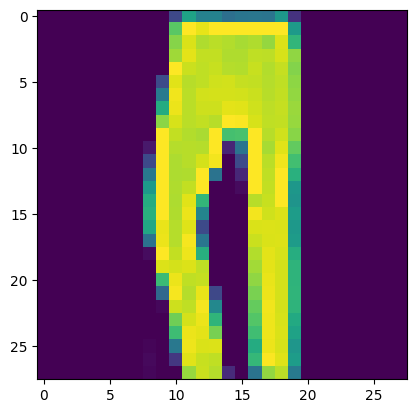

In [3]:
import matplotlib.pyplot as plt

idx = torch.randint(len(data_x), (1,)).item()
print('input data shape', data_x.shape)
print('class', data_y[idx].item())
plt.imshow(data_x[idx].permute(1, 2, 0).squeeze())

# Partie 1 : sélection d'un modèle et réglage des hyper-paramètres

On vous demande de fournir un programme informatique capable de prédire la classe d'images du jeu de données.

## a) Description
Décrire en quelques lignes le problème de prédiction en détaillant la nature et la représentation des données en entrée, des classes et de votre modèle prédictif. Comment votre programme prédit une classe à partir d'une image?

*Réponse*

**Nature des données :** Le jeu de données FashionMNIST contient des images en niveaux de gris de vêtements et accessoires, de dimension 28×28 pixels. Chaque image est représentée par un tenseur de taille (1, 28, 28) où 1 est le nombre de canaux (niveaux de gris) et les valeurs des pixels sont normalisées entre 0 et 1. L'ensemble d'apprentissage contient ici 1000 images (paramètre `batch_size`).

**Classes :** Il y a 10 classes à prédire : T-shirt/top (0), Trouser (1), Pullover (2), Dress (3), Coat (4), Sandal (5), Shirt (6), Sneaker (7), Bag (8), Ankle boot (9). Chaque image est associée à une étiquette $y \in \{0, 1, \ldots, 9\}$.

**Modèle prédictif :** On utilise un réseau de neurones à convolution (CNN). Le modèle applique des filtres de convolution qui apprennent à détecter des motifs locaux dans l'image (contours, textures, formes), suivis d'une non-linéarité ReLU, puis d'une couche entièrement connectée qui produit un vecteur de scores $z \in \mathbb{R}^{10}$.

**Prédiction :** Pour une image $x$, le modèle calcule $f(x) \in \mathbb{R}^{10}$. La classe prédite est $\hat{y} = \arg\max_{i \in \{0,\ldots,9\}} f(x)[i]$. Pour l'apprentissage, on utilise la fonction softmax suivie de la fonction de coût CrossEntropyLoss qui mesure $L = -\sum_k \log P(y_k | x_k, f)$, et on optimise les paramètres du réseau par descente de gradient stochastique.

## b) Sélection des hyper-paramètres
Choisir deux paramètres parmi
- Nombre de couches cachées
- Taille des couches cachées
- Nombre de convolutions
- Dimension de la matrice de convolution
- Nature de la non-linéarité
- Pas de la descente de gradient
- Taille du mini-batch

Pour chacun des attributs, définir deux valeurs possibles, ce qui donne 4 combinaisons au total. Pour chacune des combinaisons
- Exécuter 1000 pas de gradient, optimisant la fonction de coût `CrossEntropyLoss` (ou tout autre fonction de coût pour la classification multi-classes) et calculer chaque 100 pas de gradient la fonction de coût sur l'ensemble des données
- Afficher un graph qui montre en abscisse le nombre de pas de gradient et en ordonnée la fonction de coût
- Spécifier quel modèle/hyper-paramètres vous préconisez l'utilisation pour votre jeu de données



In [4]:
# code qui parcours le jeu de données par mini-batchs
taille_minibatch = 32
train_data_iter = DataLoader(train_dataset, shuffle=True, drop_last=True,
                             batch_size=taille_minibatch)
for x, y in train_data_iter:
  print(f'données en entrée de dimension {x.shape} et de type {x.type()}, \n\
  données de supervision de dimension {y.shape} et de type {y.type()}')
  break

données en entrée de dimension torch.Size([32, 1, 28, 28]) et de type torch.FloatTensor, 
  données de supervision de dimension torch.Size([32]) et de type torch.LongTensor


Combinaisons (lr, n_filtres) : [(0.01, 8), (0.01, 32), (0.001, 8), (0.001, 32)]

--- Entraînement : lr=0.01, filtres=8 ---
  Step 100: Loss = 1.1728
  Step 200: Loss = 0.8434
  Step 300: Loss = 0.7546
  Step 400: Loss = 0.6727
  Step 500: Loss = 0.6286
  Step 600: Loss = 0.7204
  Step 700: Loss = 0.9810
  Step 800: Loss = 0.5712
  Step 900: Loss = 0.5591
  Step 1000: Loss = 0.5432

--- Entraînement : lr=0.01, filtres=32 ---
  Step 100: Loss = 0.9622
  Step 200: Loss = 0.8126
  Step 300: Loss = 0.7192
  Step 400: Loss = 0.6149
  Step 500: Loss = 0.5353
  Step 600: Loss = 0.5348
  Step 700: Loss = 0.4956
  Step 800: Loss = 0.4985
  Step 900: Loss = 0.4515
  Step 1000: Loss = 0.4696

--- Entraînement : lr=0.001, filtres=8 ---
  Step 100: Loss = 2.2265
  Step 200: Loss = 2.1532
  Step 300: Loss = 2.0680
  Step 400: Loss = 1.9615
  Step 500: Loss = 1.8310
  Step 600: Loss = 1.6806
  Step 700: Loss = 1.5273
  Step 800: Loss = 1.3871
  Step 900: Loss = 1.2677
  Step 1000: Loss = 1.1705

--- E

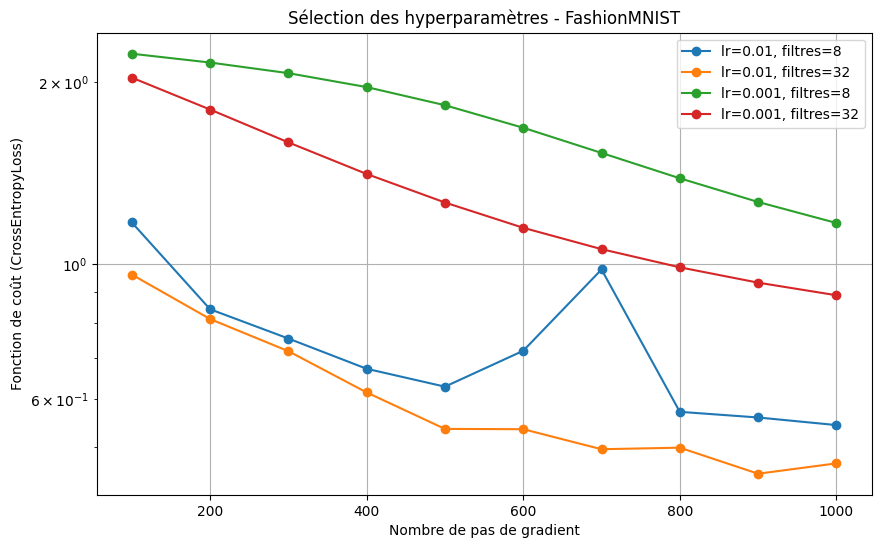

In [5]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# --- Définition du modèle CNN paramétrable ---
class CNN(nn.Module):
    def __init__(self, n_filtres, in_channels=1, img_size=28, n_classes=10):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, n_filtres, kernel_size=5, padding=2)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2)
        conv_out_size = img_size // 2  # après MaxPool2d(2) : 28->14
        self.fc = nn.Linear(n_filtres * conv_out_size * conv_out_size, n_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# --- Hyperparamètres à tester ---
# Paramètre 1 : Pas de la descente de gradient (learning rate) : {0.01, 0.001}
# Paramètre 2 : Nombre de convolutions (filtres) : {8, 32}
learning_rates = [0.01, 0.001]
n_filtres_list = [8, 32]

combinaisons = [(lr, nf) for lr in learning_rates for nf in n_filtres_list]
print("Combinaisons (lr, n_filtres) :", combinaisons)

# --- Entraînement pour chaque combinaison ---
n_steps = 1000
eval_every = 100
taille_minibatch = 32
resultats = {}

for lr, nf in combinaisons:
    label = f"lr={lr}, filtres={nf}"
    print(f"\n--- Entraînement : {label} ---")
    model = CNN(n_filtres=nf)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    train_iter = DataLoader(train_dataset, shuffle=True, drop_last=True,
                            batch_size=taille_minibatch)

    losses = []
    step = 0
    while step < n_steps:
        for x_batch, y_batch in train_iter:
            if step >= n_steps:
                break
            optimizer.zero_grad()
            output = model(x_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            step += 1

            if step % eval_every == 0:
                # Calcul du coût sur l'ensemble des données
                model.eval()
                with torch.no_grad():
                    out_all = model(data_x)
                    loss_all = criterion(out_all, data_y).item()
                model.train()
                losses.append((step, loss_all))
                print(f"  Step {step}: Loss = {loss_all:.4f}")

    resultats[label] = losses

# --- Affichage des courbes ---
plt.figure(figsize=(10, 6))
for label, losses in resultats.items():
    steps, vals = zip(*losses)
    plt.semilogy(steps, vals, '-o', label=label)
plt.xlabel("Nombre de pas de gradient")
plt.ylabel("Fonction de coût (CrossEntropyLoss)")
plt.title("Sélection des hyperparamètres - FashionMNIST")
plt.legend()
plt.grid(True)
plt.show()

### Choix du modèle / hyperparamètres préconisés

**Analyse des courbes :** On observe clairement deux groupes de comportement sur le graphe :

1. **Influence du learning rate ($\alpha$) :** Les courbes avec $\alpha = 0.01$ (bleu, orange) descendent bien plus rapidement que celles avec $\alpha = 0.001$ (vert, rouge). Cela s'explique par la formule de mise à jour de la descente de gradient $\theta^{(t+1)} = \theta^{(t)} - \alpha \nabla L(\theta^{(t)})$ : un pas $\alpha$ plus grand permet de parcourir plus vite la surface de la fonction de coût. Les courbes $\alpha = 0.001$ n'ont pas encore convergé après 1000 pas (loss $\approx 0.89\text{–}0.99$) tandis que $\alpha = 0.01$ atteint $\approx 0.46\text{–}0.50$. On ne choisit pas un $\alpha$ trop grand non plus, car cela risquerait de dépasser le minimum et de provoquer une divergence (oscillations).

2. **Influence du nombre de filtres :** À learning rate égal, 32 filtres (orange) convergent vers un coût plus bas que 8 filtres (bleu) : **$0.4627$ vs $0.4982$** à 1000 pas. Davantage de filtres de convolution permettent au réseau de détecter une plus grande variété de motifs locaux (contours, textures), ce qui enrichit les représentations de la couche cachée et améliore la capacité du modèle à discriminer les 10 classes.

**Choix préconisé : lr=0.01, filtres=32.** Cette combinaison offre à la fois la convergence la plus rapide et le coût le plus bas. Le nombre de filtres accroît la capacité d'approximation du modèle (réduction du biais au sens du compromis biais-variance), tandis que le learning rate de 0.01 permet d'atteindre un bon optimum en 1000 itérations sans signe d'instabilité numérique.

# Partie 2 : Généralisation

Pour le modèle et paramètres choisis en partie 1, effectuer 10000 pas de gradients (ou plus).

- Découper l'ensemble d'apprentissage en D1 (train) et D2 (validation).
- Calculer chaque 1000 pas le taux de bonne classification sur D1 et D2, puis tracer les courbes.
- Choisir le meilleur modèle selon D2.
- Évaluer ensuite ce meilleur modèle sur un ensemble de test séparé.
- Discuter le compromis du choix de taille D1/D2 (plus de données d'apprentissage vs meilleure fiabilité de la validation).

In [ ]:
# --- Pattern cours : split D1/D2 depuis l'ensemble d'apprentissage ---
torch.manual_seed(42)

n_total = len(data_x)
n_train_d1 = int(0.8 * n_total)
indices = torch.randperm(n_total)

idx_train_d1 = indices[:n_train_d1]
idx_val_d2 = indices[n_train_d1:]

x_train_d1, y_train_d1 = data_x[idx_train_d1], data_y[idx_train_d1]
x_val_d2, y_val_d2 = data_x[idx_val_d2], data_y[idx_val_d2]

train_d1_dataset = TensorDataset(x_train_d1, y_train_d1)

# --- Ensemble de test complet (non utilisé pour choisir le modèle) ---
test_dataset_full = dataset_loader(
    root='./', train=False, download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor()
    ])
)

test_loader_full = DataLoader(
    test_dataset_full, batch_size=256, shuffle=False
)
print(f"Taille D1 (train): {len(x_train_d1)}")
print(f"Taille D2 (validation): {len(x_val_d2)}")
print(f"Taille test complet: {len(test_dataset_full)}")

1000
Taille D1 (train): 800
Taille D2 (validation): 200
Taille test complet: 10000


Step 1000: Acc D1 = 0.8712, Acc D2 = 0.7100
Step 2000: Acc D1 = 0.9050, Acc D2 = 0.7700
Step 3000: Acc D1 = 0.9413, Acc D2 = 0.7800
Step 4000: Acc D1 = 0.9413, Acc D2 = 0.7550
Step 5000: Acc D1 = 0.9787, Acc D2 = 0.7950
Step 6000: Acc D1 = 0.9812, Acc D2 = 0.7800
Step 7000: Acc D1 = 0.9937, Acc D2 = 0.7950
Step 8000: Acc D1 = 0.9900, Acc D2 = 0.7800
Step 9000: Acc D1 = 0.9987, Acc D2 = 0.7750
Step 10000: Acc D1 = 1.0000, Acc D2 = 0.7950


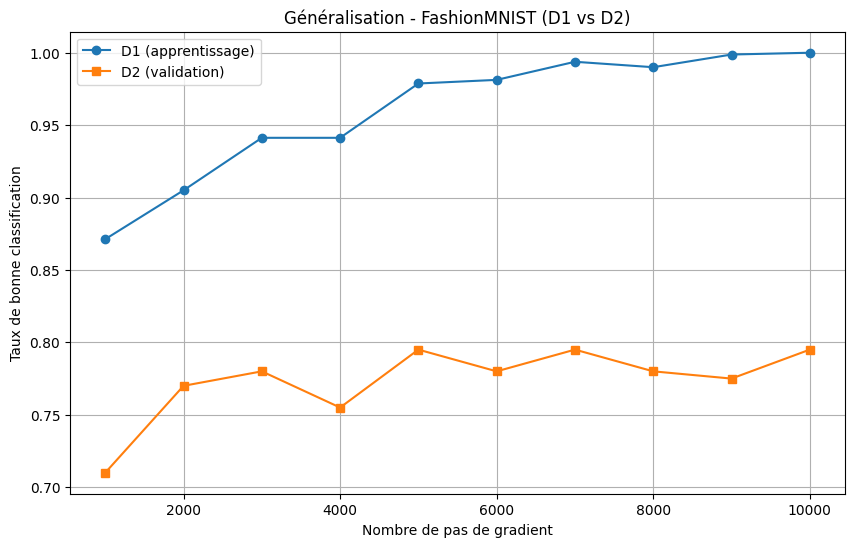


Meilleur modèle (selon D2) : step 5000 avec acc_D2 = 0.7950
  (acc_D1 = 0.9787)
Performance finale sur test complet (best_step=5000) : acc_test = 0.8054


In [7]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# --- Meilleurs hyperparamètres choisis en Partie 1 ---
best_lr = 0.01
best_nf = 32

# --- Entraînement sur 10000 pas de gradient (pattern cours: train sur D1) ---
model_gen = CNN(n_filtres=best_nf)
optimizer_gen = torch.optim.SGD(model_gen.parameters(), lr=best_lr)
criterion_gen = nn.CrossEntropyLoss()

n_steps_gen = 10000
eval_every_gen = 1000
taille_minibatch_gen = 32
train_iter_gen = DataLoader(train_d1_dataset, shuffle=True, drop_last=True,
                            batch_size=taille_minibatch_gen)

train_accuracies = []
val_accuracies = []
saved_models = {}
step = 0

while step < n_steps_gen:
    for x_batch, y_batch in train_iter_gen:
        if step >= n_steps_gen:
            break
        optimizer_gen.zero_grad()
        output = model_gen(x_batch)
        loss = criterion_gen(output, y_batch)
        loss.backward()
        optimizer_gen.step()
        step += 1

        if step % eval_every_gen == 0:
            model_gen.eval()
            with torch.no_grad():
                # Taux de bonne classification sur D1 (apprentissage)
                pred_train = model_gen(x_train_d1).argmax(dim=1)
                acc_train = (pred_train == y_train_d1).float().mean().item()

                # Taux de bonne classification sur D2 (validation)
                pred_val = model_gen(x_val_d2).argmax(dim=1)
                acc_val = (pred_val == y_val_d2).float().mean().item()

            model_gen.train()
            train_accuracies.append((step, acc_train))
            val_accuracies.append((step, acc_val))
            # Sauvegarder les poids du modèle à cette étape
            saved_models[step] = {
                'state_dict': {k: v.clone() for k, v in model_gen.state_dict().items()},
                'acc_val': acc_val,
                'acc_train': acc_train
            }
            print(f"Step {step}: Acc D1 = {acc_train:.4f}, Acc D2 = {acc_val:.4f}")

# --- Affichage des courbes D1/D2 ---
plt.figure(figsize=(10, 6))
steps_t, accs_t = zip(*train_accuracies)
steps_v, accs_v = zip(*val_accuracies)
plt.plot(steps_t, accs_t, '-o', label="D1 (apprentissage)")
plt.plot(steps_v, accs_v, '-s', label="D2 (validation)")
plt.xlabel("Nombre de pas de gradient")
plt.ylabel("Taux de bonne classification")
plt.title("Généralisation - FashionMNIST (D1 vs D2)")
plt.legend()
plt.grid(True)
plt.show()

# --- Choix du meilleur modèle via D2 ---
best_step = max(saved_models, key=lambda s: saved_models[s]['acc_val'])
print(f"\nMeilleur modèle (selon D2) : step {best_step} avec acc_D2 = {saved_models[best_step]['acc_val']:.4f}")
print(f"  (acc_D1 = {saved_models[best_step]['acc_train']:.4f})")

# --- Évaluation finale sur test complet (non utilisé pendant la sélection) ---
model_gen.load_state_dict(saved_models[best_step]['state_dict'])
model_gen.eval()
correct_test = 0
total_test = 0
with torch.no_grad():
    for x_test_batch, y_test_batch in test_loader_full:
        pred_test_batch = model_gen(x_test_batch).argmax(dim=1)
        correct_test += (pred_test_batch == y_test_batch).sum().item()
        total_test += y_test_batch.size(0)

acc_test_best = correct_test / total_test
print(f"Performance finale sur test complet (best_step={best_step}) : acc_test = {acc_test_best:.4f}")

### Analyse de la généralisation

**Protocole appliqué :**
- On découpe l'ensemble d'apprentissage en **D1 (train, 80%)** et **D2 (validation, 20%)**.
- L'entraînement est fait uniquement sur D1.
- Le choix du modèle est fait avec la performance sur D2.
- L'ensemble **test** (`train=False`) est gardé à part et utilisé seulement à la fin.

**Observation D1 vs D2 :** On observe un écart croissant entre la performance sur D1 et celle sur D2 lorsque le nombre de pas de gradient augmente. Cela indique du **sur-apprentissage** : le modèle continue d'améliorer le risque empirique sur D1, mais ne généralise pas autant sur des données non vues (D2).

**Lien avec le compromis biais-variance :**
$$\mathbb{E}_D[R(A(D))] = \text{Biais}^2 + \text{Variance} + \sigma^2$$
Augmenter la capacité d'ajustement (plus d'itérations) réduit le biais sur D1, mais peut augmenter la variance, ce qui se manifeste par un plateau voire une baisse relative sur D2.

**Choix du modèle :** Le modèle retenu est celui qui maximise la performance sur D2 (affiché dans la cellule de code).

**Vérification finale sur test :** Après sélection via D2, on évalue le checkpoint retenu sur le test séparé (`acc_test_best` affichée dans la cellule), ce qui respecte le schéma du cours.

**Compromis taille D1/D2 :**
- D1 plus grand: apprentissage plus stable (biais plus faible), mais validation moins fiable (variance de l'estimation de performance plus élevée).
- D2 plus grand: sélection de modèle plus fiable, mais moins de données pour apprendre.
Un compromis 80/20 est un choix standard cohérent ici.

# Partie 3 : Interprétation

Pour un couple image-classe $(x, y)$ donné, calculer la dérivée de la sortie de votre modèle associée à la classe $y$ par rapport à l'entrée $x$, puis afficher la valeur absolue de ce gradient comme une image (utiliser la même fonction ``imshow`` utilisée plus haut pour afficher une image).

Est-ce que ce gradient permet d'expliquer en théorie quelles parties de l'image ont le plus d'impact sur la décision du modèle ? Est-ce que cela fait sens pour votre exemple $(x, y)$ en pratique ? Justifier vos réponses.


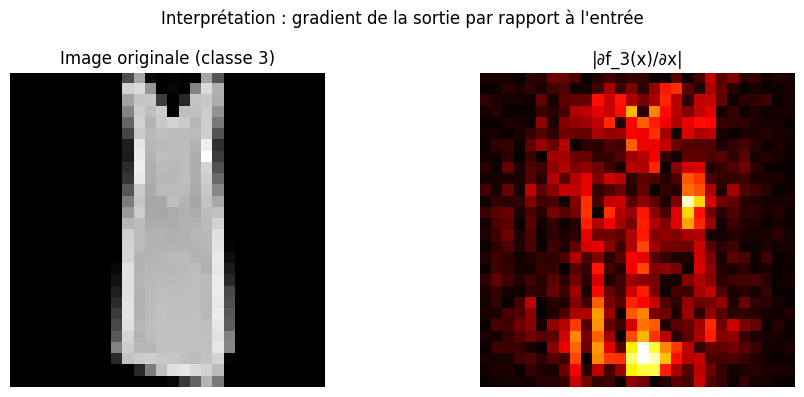

Classe réelle : 3
Classe prédite : 3


In [8]:
import torch
import matplotlib.pyplot as plt

# Fixer la graine pour rendre l'exemple reproductible
torch.manual_seed(42)

# --- Charger le meilleur modèle de la Partie 2 ---
model_interp = CNN(n_filtres=best_nf)
model_interp.load_state_dict(saved_models[best_step]['state_dict'])
model_interp.eval()

# --- Choisir un couple (x, y) ---
idx = torch.randint(len(data_x), (1,)).item()
x_sample = data_x[idx:idx+1].clone().detach().requires_grad_(True)
y_sample = data_y[idx].item()

# --- Calcul de la sortie du modèle et du gradient ---
output = model_interp(x_sample)
# On prend la sortie associée à la classe y
score_y = output[0, y_sample]
score_y.backward()

# --- Gradient par rapport à l'entrée x ---
grad_x = x_sample.grad.data.abs()  # valeur absolue du gradient

# --- Affichage ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Image originale
axes[0].imshow(data_x[idx].permute(1, 2, 0).squeeze(), cmap='gray')
axes[0].set_title(f"Image originale (classe {y_sample})")
axes[0].axis('off')

# Gradient (valeur absolue)
axes[1].imshow(grad_x[0].permute(1, 2, 0).squeeze().detach(), cmap='hot')
axes[1].set_title(f"|∂f_{y_sample}(x)/∂x|")
axes[1].axis('off')

plt.suptitle("Interprétation : gradient de la sortie par rapport à l'entrée")
plt.tight_layout()
plt.show()

print(f"Classe réelle : {y_sample}")
print(f"Classe prédite : {output.argmax(dim=1).item()}")

### Interprétation du gradient

**En théorie :** Le gradient $\frac{\partial f_y(x)}{\partial x} \in \mathbb{R}^{1 \times 28 \times 28}$ mesure, pour chaque pixel $x_i$, à quel point une petite perturbation $\epsilon$ de ce pixel influence le score $f_y(x)$ associé à la classe $y$. Formellement, par définition de la dérivée directionnelle (cf. cours) :
$$\lim_{\alpha \to 0} \frac{f_y(x + \alpha e_i) - f_y(x)}{\alpha} = \frac{\partial f_y}{\partial x_i}(x)$$
où $e_i$ est le vecteur unitaire dans la direction du pixel $i$. La valeur absolue $\left|\frac{\partial f_y}{\partial x_i}\right|$ indique donc l'importance de chaque pixel pour la décision du modèle : plus elle est grande, plus le pixel $i$ a un impact fort sur le score de la classe $y$.

**En pratique (notre exemple reproductible) :** Avec la graine fixe, l'image tirée est une **Dress (classe 3)** et le modèle prédit aussi 3. Sur la saliency map, les zones de fort gradient (couleurs chaudes) se concentrent surtout sur :
- La **silhouette verticale centrale** du vêtement (zone du buste et de la jupe)
- Les **bords/contours** de la robe (épaules, côtés, bas), qui structurent la forme globale

Le fond noir reste peu activé, ce qui est cohérent : la décision dépend surtout des pixels de l'objet. Cela fait sens pour la classe Dress, où la forme allongée et les contours du vêtement sont discriminants.

**Limites de cette approche :** La saliency map basée sur le gradient est une méthode d'interprétation *locale* (valide au voisinage de $x$) et *de premier ordre* (approximation linéaire). Elle peut être bruitée car le gradient de réseaux profonds est souvent irrégulier. Des méthodes plus avancées existent (SmoothGrad, Grad-CAM) qui lissent ou agrègent les gradients pour une interprétation plus stable. De plus, un fort gradient en un pixel signifie que ce pixel est *sensible*, mais pas nécessairement que le modèle le « regarde » activement — ce sont deux notions distinctes.